In [1]:
import os
print(os.getcwd())

/Users/dts/projects/protein-function-ml/notebooks


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("../data/processed/features.csv")
print(df.shape)
df.head()

(9961, 428)


,Entry,function_category,A,C,D,E,F,G,H,I,...,YT,YV,YW,YY,length,molecular_weight,gravy,net_charge_ph7,isoelectric_point,aromaticity
0,A0A087X1C5,enzyme,0.081553,0.017476,0.044660,0.054369,0.060194,0.069903,0.031068,0.031068,...,0.000000,0.000000,0.00000,0.000000,515,57488.0269,-0.016117,5.889114,8.703506,0.085437
1,A0A1B0GTW7,enzyme,0.068528,0.036802,0.034264,0.044416,0.024112,0.090102,0.038071,0.021574,...,0.000000,0.001271,0.00000,0.001271,788,85395.9714,-0.141624,5.910724,8.038192,0.065990
2,A0AVI4,enzyme,0.110497,0.049724,0.033149,0.046961,0.041436,0.035912,0.027624,0.030387,...,0.000000,0.002770,0.00277,0.005540,362,40463.4776,0.175138,2.237883,7.836471,0.096685
3,A0AVT1,enzyme,0.068441,0.021863,0.056084,0.073194,0.051331,0.051331,0.029468,0.063688,...,0.001903,0.004757,0.00000,0.000951,1052,117968.5752,-0.233840,-21.840516,5.761905,0.086502
4,A1A4Y4,enzyme,0.077348,0.011050,0.038674,0.077348,0.038674,0.055249,0.016575,0.044199,...,0.000000,0.000000,0.00000,0.000000,181,20141.8231,-0.186188,-5.225778,5.226027,0.077348


In [3]:
feature_cols = [c for c in df.columns if c not in ("Entry", "function_category")]
X = df[feature_cols].values
y = df["function_category"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X.shape, X_scaled.shape)

(9961, 426) (9961, 426)


In [4]:
pca = PCA(n_components=20, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()

for i in range(10):
    print(f"PC{i+1}: {explained[i]*100:5.2f}% (cumulative {cumulative[i]*100:5.2f}%)")

PC1:  4.63% (cumulative  4.63%)
PC2:  3.89% (cumulative  8.52%)
PC3:  3.04% (cumulative 11.56%)
PC4:  1.70% (cumulative 13.26%)
PC5:  1.49% (cumulative 14.76%)
PC6:  1.41% (cumulative 16.17%)
PC7:  1.17% (cumulative 17.34%)
PC8:  1.05% (cumulative 18.39%)
PC9:  1.04% (cumulative 19.43%)
PC10:  0.94% (cumulative 20.37%)


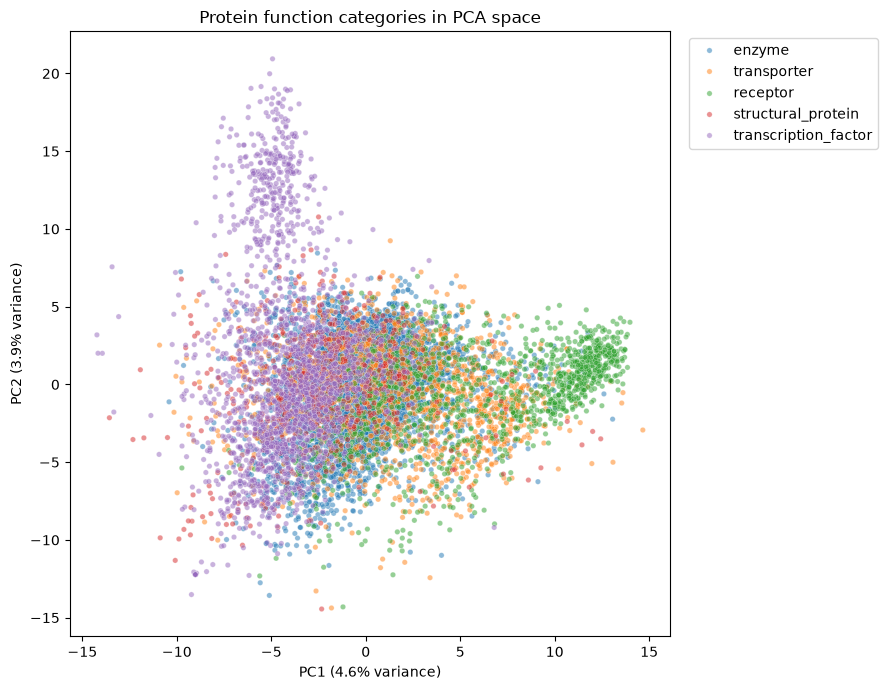

In [5]:
plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "function_category": y,
})

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=plot_df, x="PC1", y="PC2",
    hue="function_category", alpha=0.5, s=15,
)
plt.xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
plt.title("Protein function categories in PCA space")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../results/figures/pca_scatter.png", dpi=150)
plt.show()

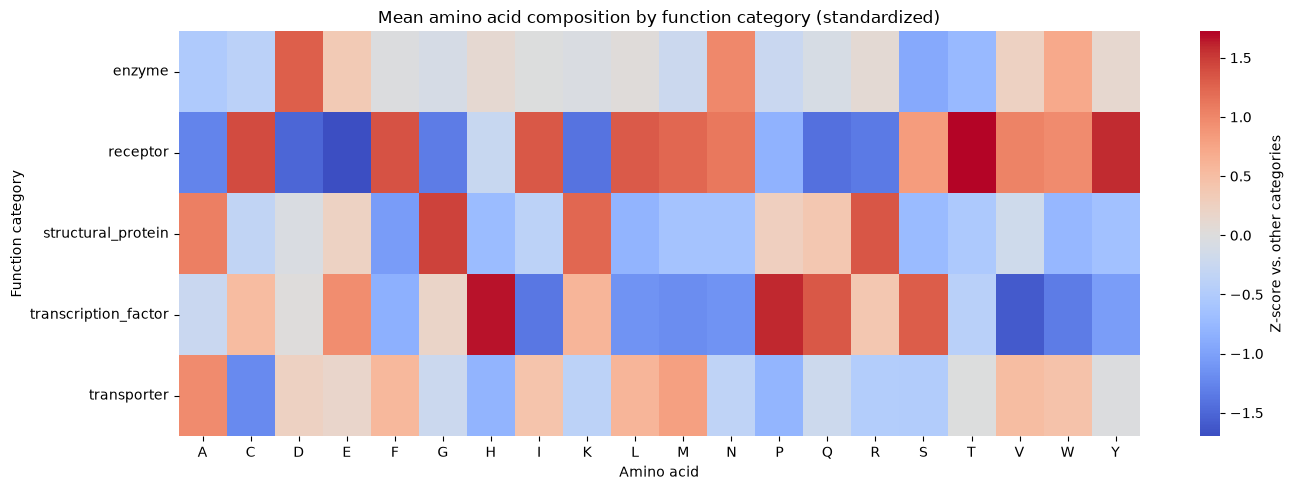

In [6]:
aa_cols = list("ACDEFGHIKLMNPQRSTVWY")
aa_means = df.groupby("function_category")[aa_cols].mean()
aa_means_z = (aa_means - aa_means.mean()) / aa_means.std()

plt.figure(figsize=(14, 5))
sns.heatmap(
    aa_means_z, cmap="coolwarm", center=0,
    cbar_kws={"label": "Z-score vs. other categories"},
)
plt.title("Mean amino acid composition by function category (standardized)")
plt.xlabel("Amino acid")
plt.ylabel("Function category")
plt.tight_layout()
plt.savefig("../results/figures/aa_composition_heatmap.png", dpi=150)
plt.show()

In [7]:
phys_cols = ["gravy", "net_charge_ph7", "isoelectric_point", "aromaticity", "molecular_weight"]
df.groupby("function_category")[phys_cols].mean()

,gravy,net_charge_ph7,isoelectric_point,aromaticity,molecular_weight
function_category,,,,,
enzyme,-0.297384,-1.138615,7.212168,0.086148,61711.716698
receptor,0.277300,2.972590,7.928471,0.107524,45697.754079
structural_protein,-0.500452,2.838317,8.071455,0.067846,51335.721987
transcription_factor,-0.680086,5.593534,7.730068,0.066787,61006.600206
transporter,-0.097831,-3.502024,7.114470,0.090993,58253.973983
